# EDA et Prétraitement 





**Import des librairies nécessaires.**

In [87]:
!pip install statsmodels


In [88]:
# Cellule imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif, SelectKBest, VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# stats / VIF
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# imbalanced-learn (SMOTE)
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# utilitaires
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")


Libraries loaded.



**Chargement des données**


In [89]:
DATA_PATH = r"C:\Users\user\Documents\projets\projet_plateforme\projet_plateforme\projet_MLP_multicouche\ANN-playground\data.csv"

# Vérifier que le fichier existe
assert os.path.exists(DATA_PATH), f"Fichier non trouvé : {DATA_PATH}"

df = pd.read_csv(DATA_PATH, sep=None, engine='python')  

# Nettoyage noms de colonnes (trim, enlever tabulations / BOM)
df.columns = df.columns.str.strip().str.replace('\t','').str.replace('\n','').str.replace('\ufeff','')
df.head(5)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Vérifications initiales**

In [90]:
print("Shape:", df.shape)
print("\nColumns and dtypes:")
display(df.dtypes)
print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(30))
print("\nNumber of duplicated rows:", df.duplicated().sum())


Shape: (4424, 37)

Columns and dtypes:


Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        


Missing values per column:


Marital status                                    0
Age at enrollment                                 0
Curricular units 1st sem (credited)               0
Curricular units 1st sem (enrolled)               0
Curricular units 1st sem (evaluations)            0
Curricular units 1st sem (approved)               0
Curricular units 1st sem (grade)                  0
Curricular units 1st sem (without evaluations)    0
Curricular units 2nd sem (credited)               0
Curricular units 2nd sem (enrolled)               0
Curricular units 2nd sem (evaluations)            0
Curricular units 2nd sem (approved)               0
Curricular units 2nd sem (grade)                  0
Curricular units 2nd sem (without evaluations)    0
Unemployment rate                                 0
Inflation rate                                    0
GDP                                               0
International                                     0
Scholarship holder                                0
Application 


Number of duplicated rows: 0


L’inspection initiale montre que le dataset contient 4424 observations et 37 variables, ce qui constitue une base solide pour entraîner un modèle MLP. Les colonnes présentent trois types distincts :

  - Variables numériques continues (notes, indicateurs économiques…), qui nécessiteront une standardisation.

  - Variables entières représentant des catégories (statut marital, qualification des parents, mode d’application…), qui devront être traitées comme des variables catégorielles lors du prétraitement.

  - La variable cible Target, de type texte, représentant le statut final de l’étudiant, qui devra être encodée en classes numériques puis en one-hot.

Un autre résultat important est l’absence totale de valeurs manquantes dans le dataset et l’absence de lignes dupliquées, ce qui simplifie considérablement le pipeline de prétraitement.

**Statistiques descriptives & distribution de la cible**

Statistiques descriptives des variables numériques :


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


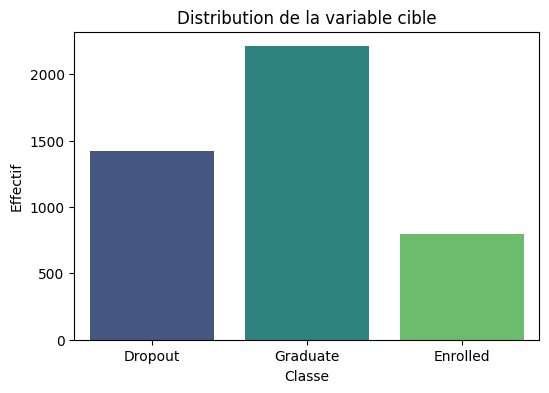


Répartition des classes :


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Proportions (%):


Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

In [ ]:
# Statistiques descriptives des variables numériques 
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Target', errors='ignore')

print("Statistiques descriptives des variables numériques :")
display(df[num_cols].describe().T)

# Distribution de la variable cible 
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Target', palette='viridis')
plt.title("Distribution de la variable cible")
plt.xlabel("Classe")
plt.ylabel("Effectif")
plt.show()

print("\nRépartition des classes :")
display(df['Target'].value_counts())
print("\nProportions (%):")
display(df['Target'].value_counts(normalize=True) * 100)


es statistiques descriptives montrent que le dataset comporte 4424 observations et 37 variables. Plusieurs variables présentent une faible variabilité, notamment Educational special needs, International ou Daytime/evening attendance, ce qui indique qu’elles auront probablement un impact limité sur le modèle.
Certaines colonnes comme Mother's occupation, Father's occupation, Nacionality ou Previous qualification présentent des valeurs extrêmes ou des écarts très importants, suggérant des catégories rares susceptibles d’être regroupées ou traitées différemment.

Les variables liées aux performances académiques (grades, approved units, evaluations, etc.) montrent une variabilité cohérente et devraient être fortement prédictives car elles reflètent directement le comportement scolaire des étudiants.

Les variables macro-économiques (chômage, inflation, PIB) semblent stables mais leur utilité devra être confirmée lors de l’analyse des corrélations.

La variable cible est modérément déséquilibrée

Nettoyage de la variable Target

In [92]:
print("Valeurs uniques initiales dans Target :", df["Target"].unique())

# Suppression des étudiants encore inscrits ("Enrolled")
df = df[df["Target"] != "Enrolled"].copy()

print("\nDistribution après suppression des 'Enrolled' :")
print(df["Target"].value_counts())

# Réinitialisation de l'index pour éviter les trous
df.reset_index(drop=True, inplace=True)

print("\nTaille du dataset après nettoyage :", df.shape)


Valeurs uniques initiales dans Target : ['Dropout' 'Graduate' 'Enrolled']

Distribution après suppression des 'Enrolled' :
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Taille du dataset après nettoyage : (3630, 37)


Les étudiants "Enrolled" sont encore en cours d’étude, leur statut final est inconnu.
Les garder aurait faussé l’entraînement car ils ne sont ni réussite ni abandon.

Ce nettoyage rend le problème binaire (Graduate et Dropout), plus propre, plus cohérent, et facilitera une meilleure modélisation.

**Visualisation des distributions**

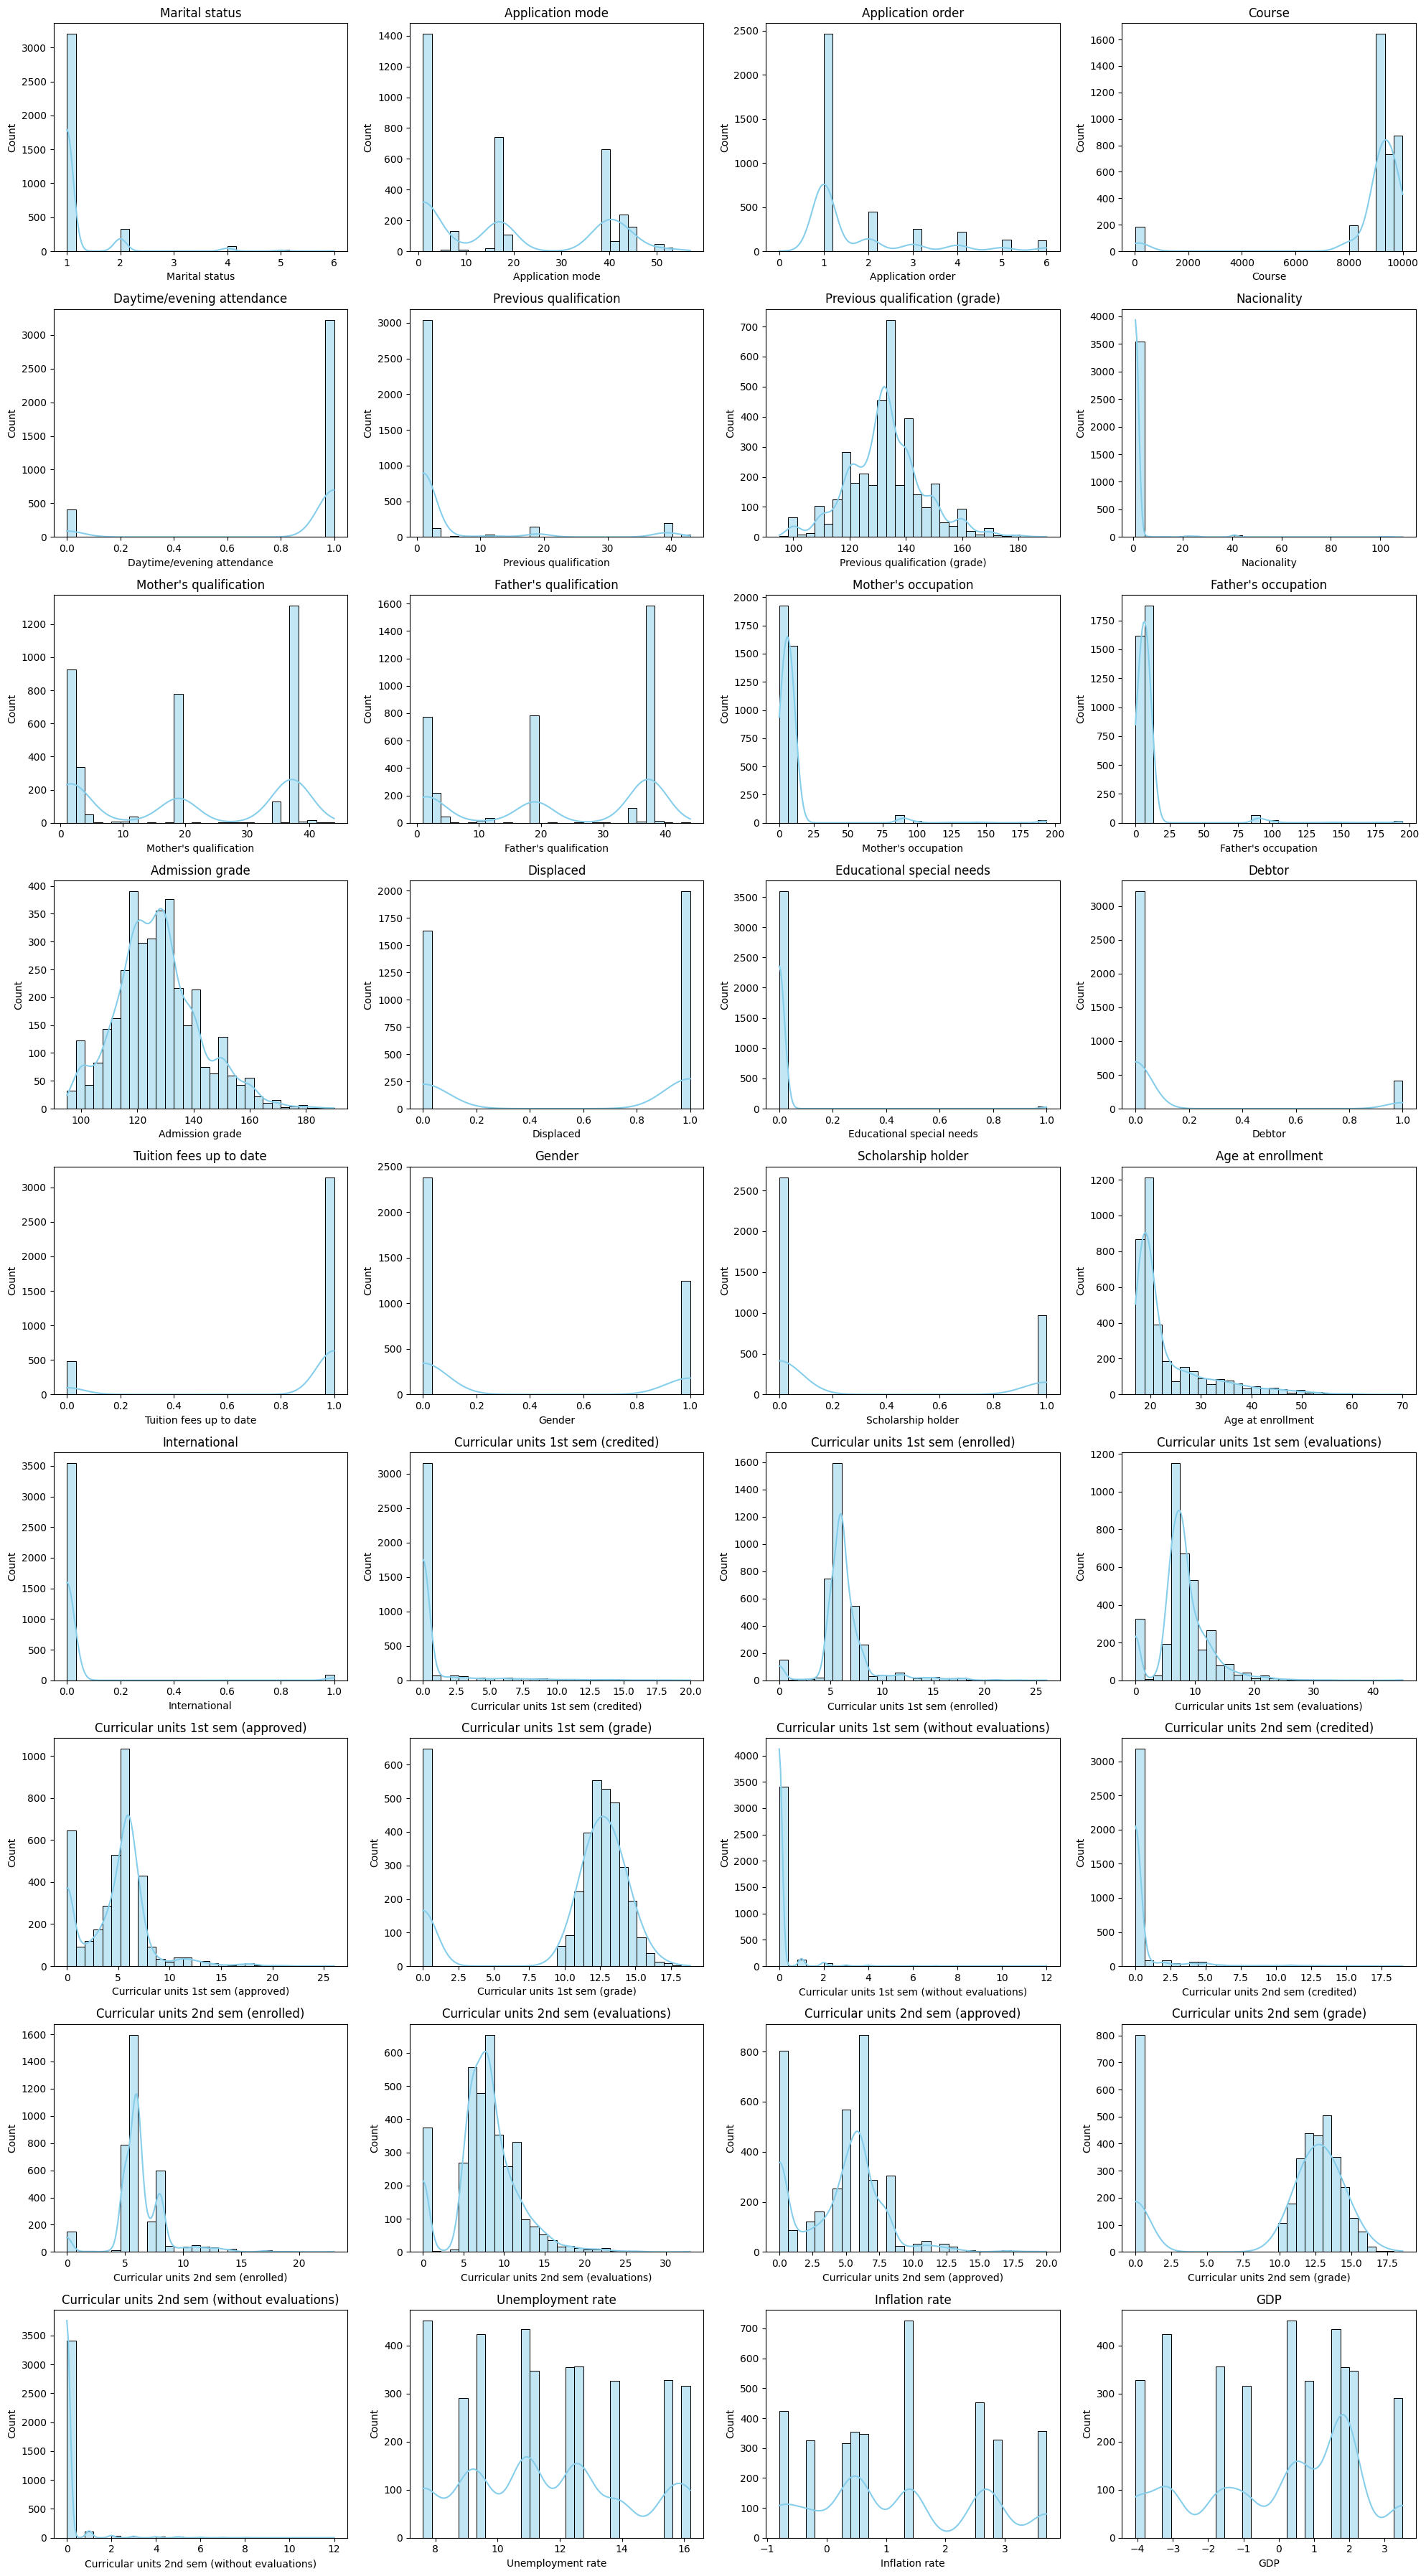

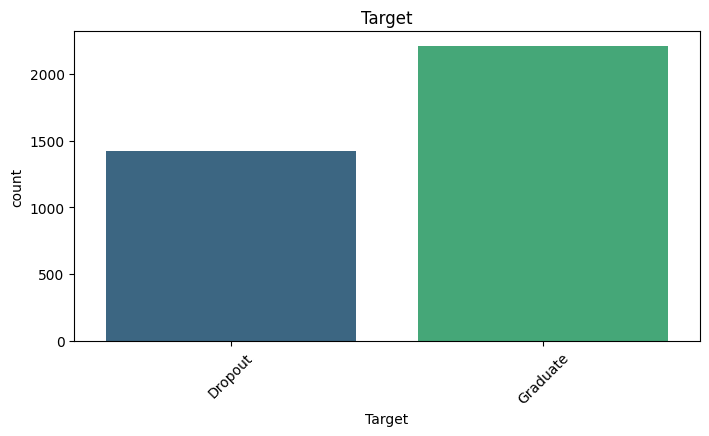

In [93]:
# 1) Variables numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_num = len(numeric_cols)
cols = 4                      # 4 graphiques par ligne
rows = int(np.ceil(n_num / cols))

plt.figure(figsize=(20, rows * 4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=True, bins=30, color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()

# 2) Variables catégorielles
categorical_cols = df.select_dtypes(include=["object"]).columns

plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(5, 3, i)
    sns.countplot(data=df, x=col, palette="viridis")
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

L’analyse exploratoire des distributions montre que plusieurs variables présentent une forte asymétrie ou très peu de variabilité : un grand nombre de variables binaires sont dominées par une seule modalité (souvent la valeur 0 ou 1), ce qui suggère un pouvoir discriminant limité. D’autres variables numériques (âge, unités curriculaires, occupations) montrent une distribution très asymétrique avec des valeurs extrêmes, tandis que les variables liées aux notes (admission grade, previous qualification grade, curricular grades) présentent des formes plus régulières et devraient être informatives pour la modélisation.

La distribution de la variable cible après suppression des étudiants "Enrolled" montre deux classes : Graduate et Dropout. L’ensemble reste modérément déséquilibré mais encore exploitable sans techniques de rééchantillonnage lourdes.
Ces résultats guideront la sélection de variables, la normalisation et la construction du pipeline de modélisation MLP.

**Matrice de corrélation et Heatmap complète**

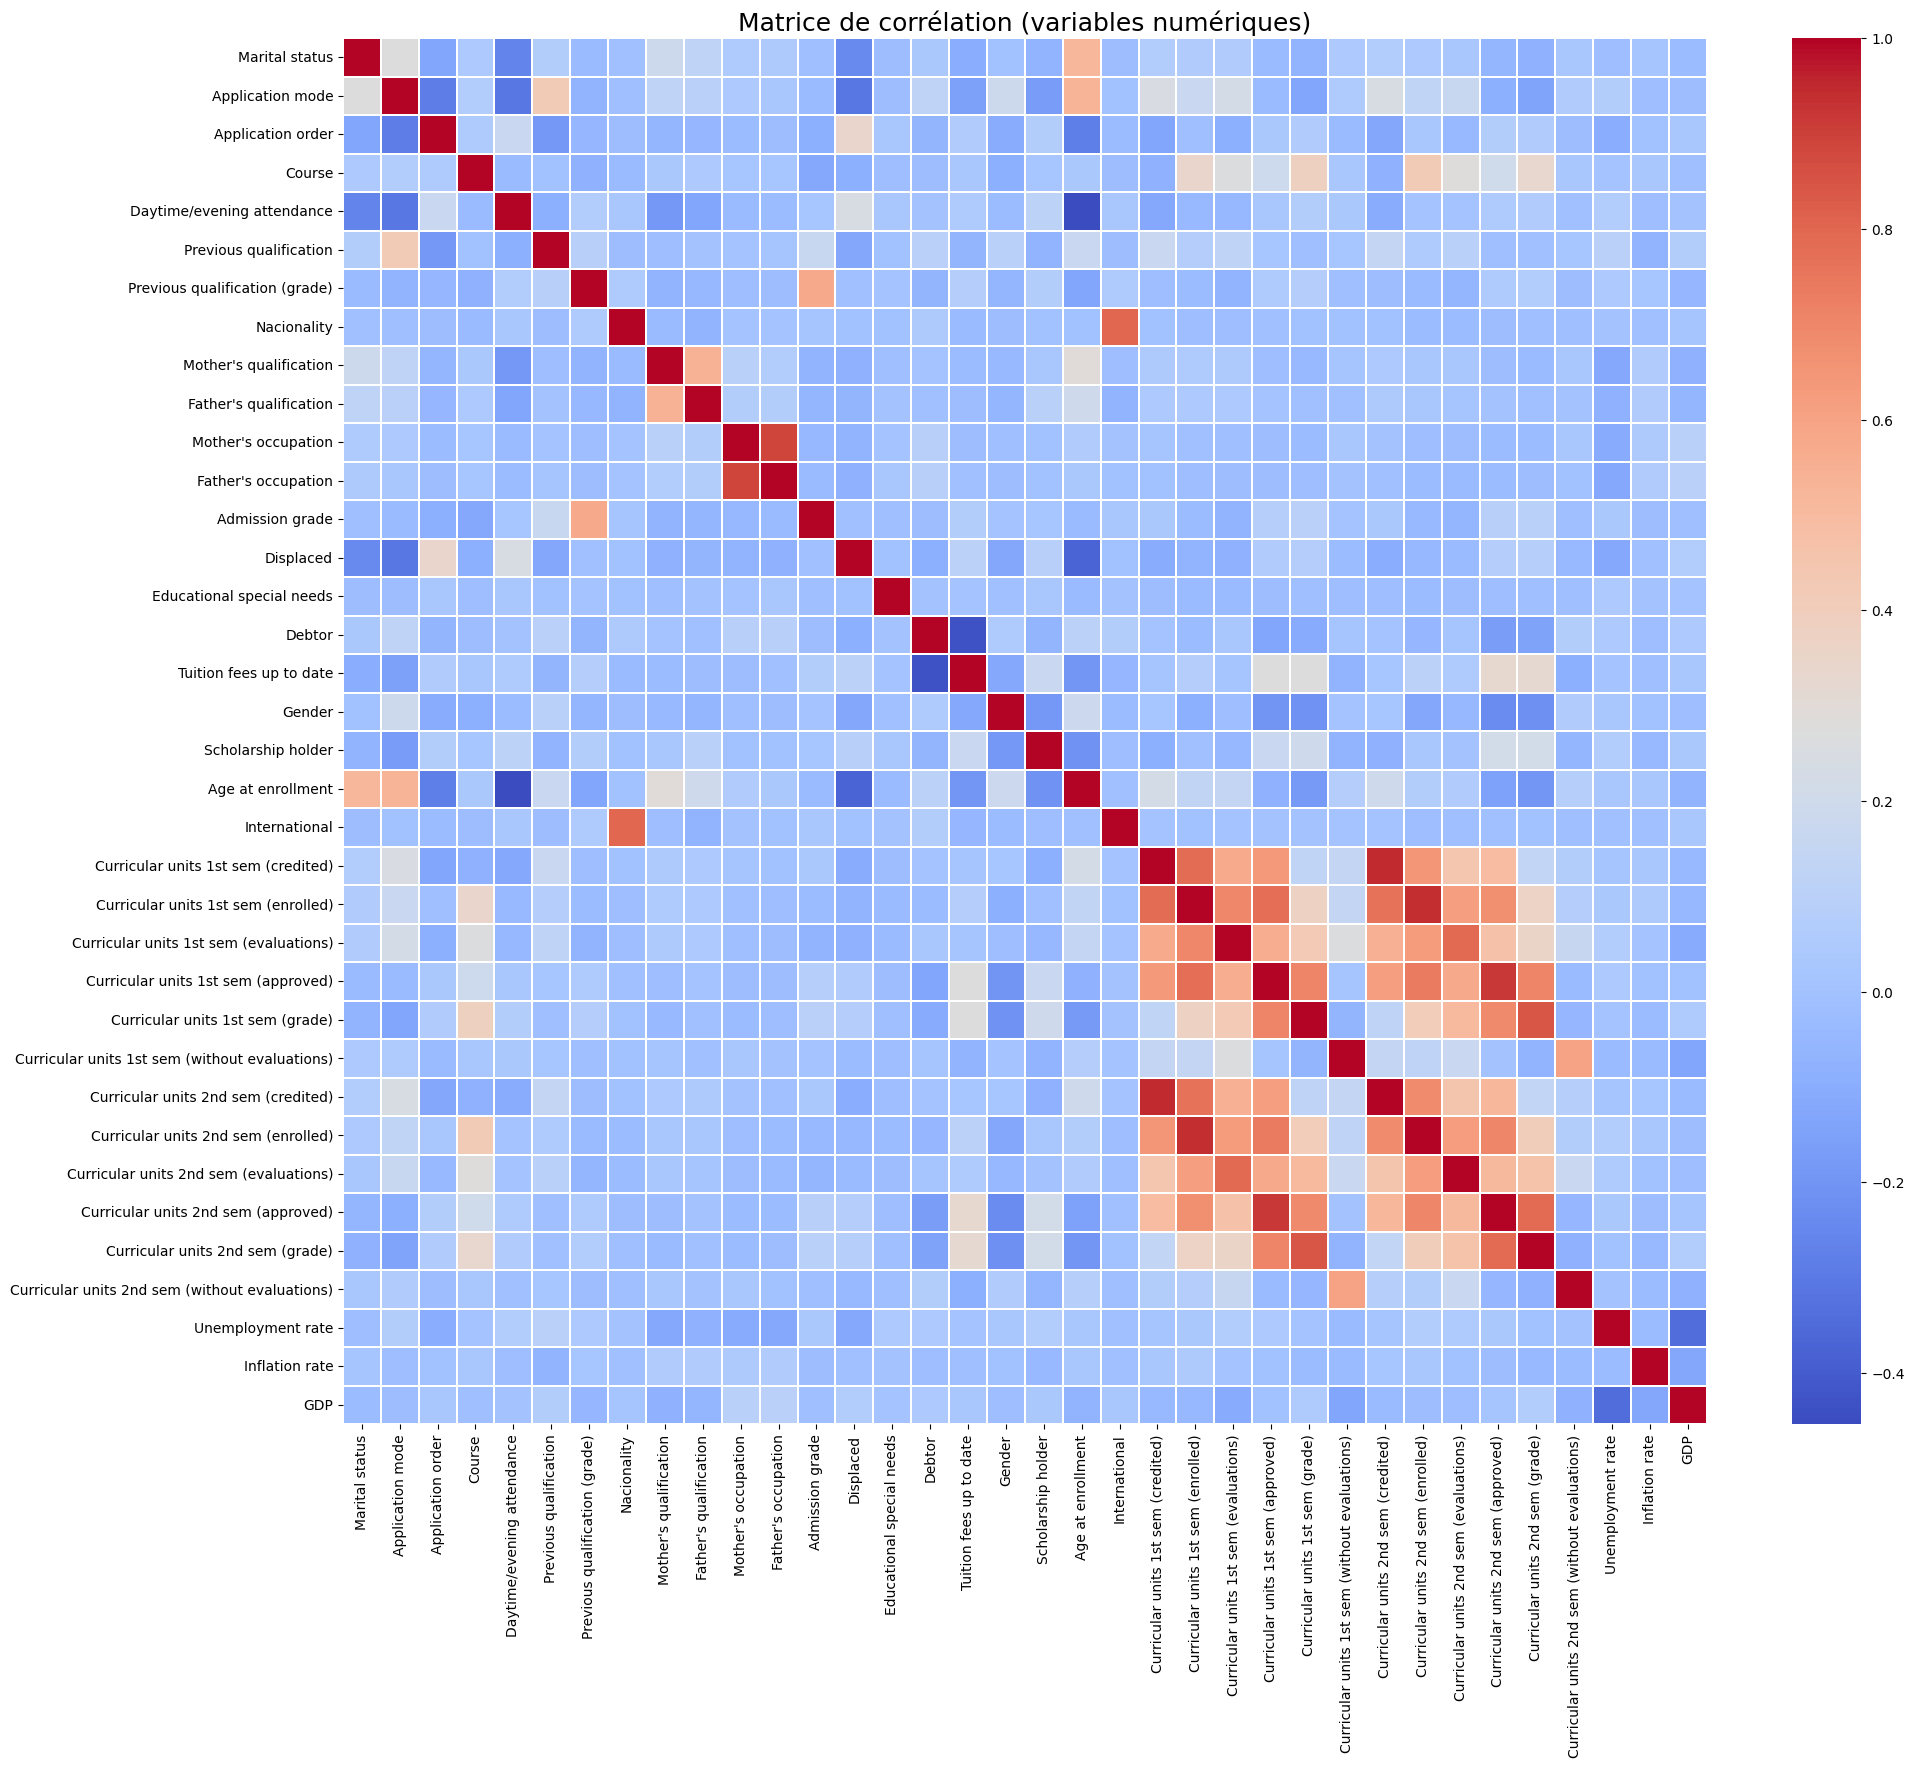


 Top 20 corrélations POSITIVES :


Curricular units 2nd sem (credited)     Curricular units 1st sem (credited)       0.947093
Curricular units 1st sem (credited)     Curricular units 2nd sem (credited)       0.947093
Curricular units 2nd sem (enrolled)     Curricular units 1st sem (enrolled)       0.941286
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (enrolled)       0.941286
Curricular units 2nd sem (approved)     Curricular units 1st sem (approved)       0.916334
Curricular units 1st sem (approved)     Curricular units 2nd sem (approved)       0.916334
Father's occupation                     Mother's occupation                       0.886568
Mother's occupation                     Father's occupation                       0.886568
Curricular units 2nd sem (grade)        Curricular units 1st sem (grade)          0.845864
Curricular units 1st sem (grade)        Curricular units 2nd sem (grade)          0.845864
Nacionality                             International                             0.797387


 Top 20 corrélations NÉGATIVES :


Displaced                   Application mode             -0.308730
Application mode            Displaced                    -0.308730
Daytime/evening attendance  Application mode             -0.310854
Application mode            Daytime/evening attendance   -0.310854
Unemployment rate           GDP                          -0.341742
GDP                         Unemployment rate            -0.341742
Displaced                   Age at enrollment            -0.370018
Age at enrollment           Displaced                    -0.370018
Tuition fees up to date     Debtor                       -0.434906
Debtor                      Tuition fees up to date      -0.434906
Daytime/evening attendance  Age at enrollment            -0.453741
Age at enrollment           Daytime/evening attendance   -0.453741
dtype: float64

In [94]:
plt.figure(figsize=(22, 18))

# On ne prend que les colonnes numériques (Target n'est pas incluse)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=False,
            linewidths=0.3)
plt.title("Matrice de corrélation (variables numériques)", fontsize=18)
plt.show()

# Afficher les plus fortes corrélations (positives et négatives)
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)

print("\n Top 20 corrélations POSITIVES :")
display(corr_pairs[(corr_pairs < 1) & (corr_pairs > 0.4)].head(20))

print("\n Top 20 corrélations NÉGATIVES :")
display(corr_pairs[(corr_pairs < -0.3)].head(20))


La matrice de corrélation montre de fortes redondances entre les variables académiques du 1er et 2e semestre (corrélations > 0.9), ce qui indique une multicolinéarité importante. Les occupations des parents sont également très corrélées (~0.88). À l’inverse, certaines variables sont logiquement corrélées négativement (Debtor, Tuition fees, Age, Evening attendance). Pour un MLP, ces corrélations ne posent pas un problème aussi critique qu’en régression, mais il est préférable de réduire les variables dupliquées pour simplifier l’apprentissage, éviter le bruit et améliorer les performances.

**Identifier automatiquement toutes les variables redondantes (>0.9)**

In [95]:
corr_matrix = df[numeric_cols].corr().abs()

# On garde seulement la moitié supérieure de la matrice
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Liste des variables corrélées au-dessus du seuil
threshold = 0.90
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if upper.loc[row, col] > threshold]

print("🔍 Variables avec corrélation > 0.90 :\n")
for a, b, v in high_corr_pairs:
    print(f"{a}  ↔  {b}  | corr = {v:.3f}")

print("\nNombre de paires très corrélées :", len(high_corr_pairs))

🔍 Variables avec corrélation > 0.90 :

Curricular units 2nd sem (credited)  ↔  Curricular units 1st sem (credited)  | corr = 0.947
Curricular units 2nd sem (enrolled)  ↔  Curricular units 1st sem (enrolled)  | corr = 0.941
Curricular units 2nd sem (approved)  ↔  Curricular units 1st sem (approved)  | corr = 0.916

Nombre de paires très corrélées : 3


on constate que la multicolinéarité est très concentrée uniquement dans les variables académiques 1er semestre et 2e semestre.

Le dataset contient donc des doublons temporels. Ce qui est problématique pour plusieurs raisons : 
   - Le réseau va apprendre deux fois la  même information (surajustement)
   - Perte de généralisation
   - Perte de vitesse d’apprentissage
   - Les poids deviennent instables
Il serait bien donc de réduire la redondance.

**Suppression des variables du 2nd semestre (très corrélées)**


In [96]:
cols_to_drop = [
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

df_reduced = df.drop(columns=cols_to_drop)

print("Colonnes supprimées :", cols_to_drop)
print("Nouveau shape :", df_reduced.shape)


Colonnes supprimées : ['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']
Nouveau shape : (3630, 31)


**matrice de corrélation après réduction**

Cette étape est essentielle pour valider la suppression du bruit et voir si d’autres redondances doivent être traitées.
En effet, une fois les corrélations extrêmes enlevées, il faut vérifier si des correlations modérément élevées persistent.

Ainsi, on utilise un seuil de 0.85 pour affiner et inspecter les redondances possibles 

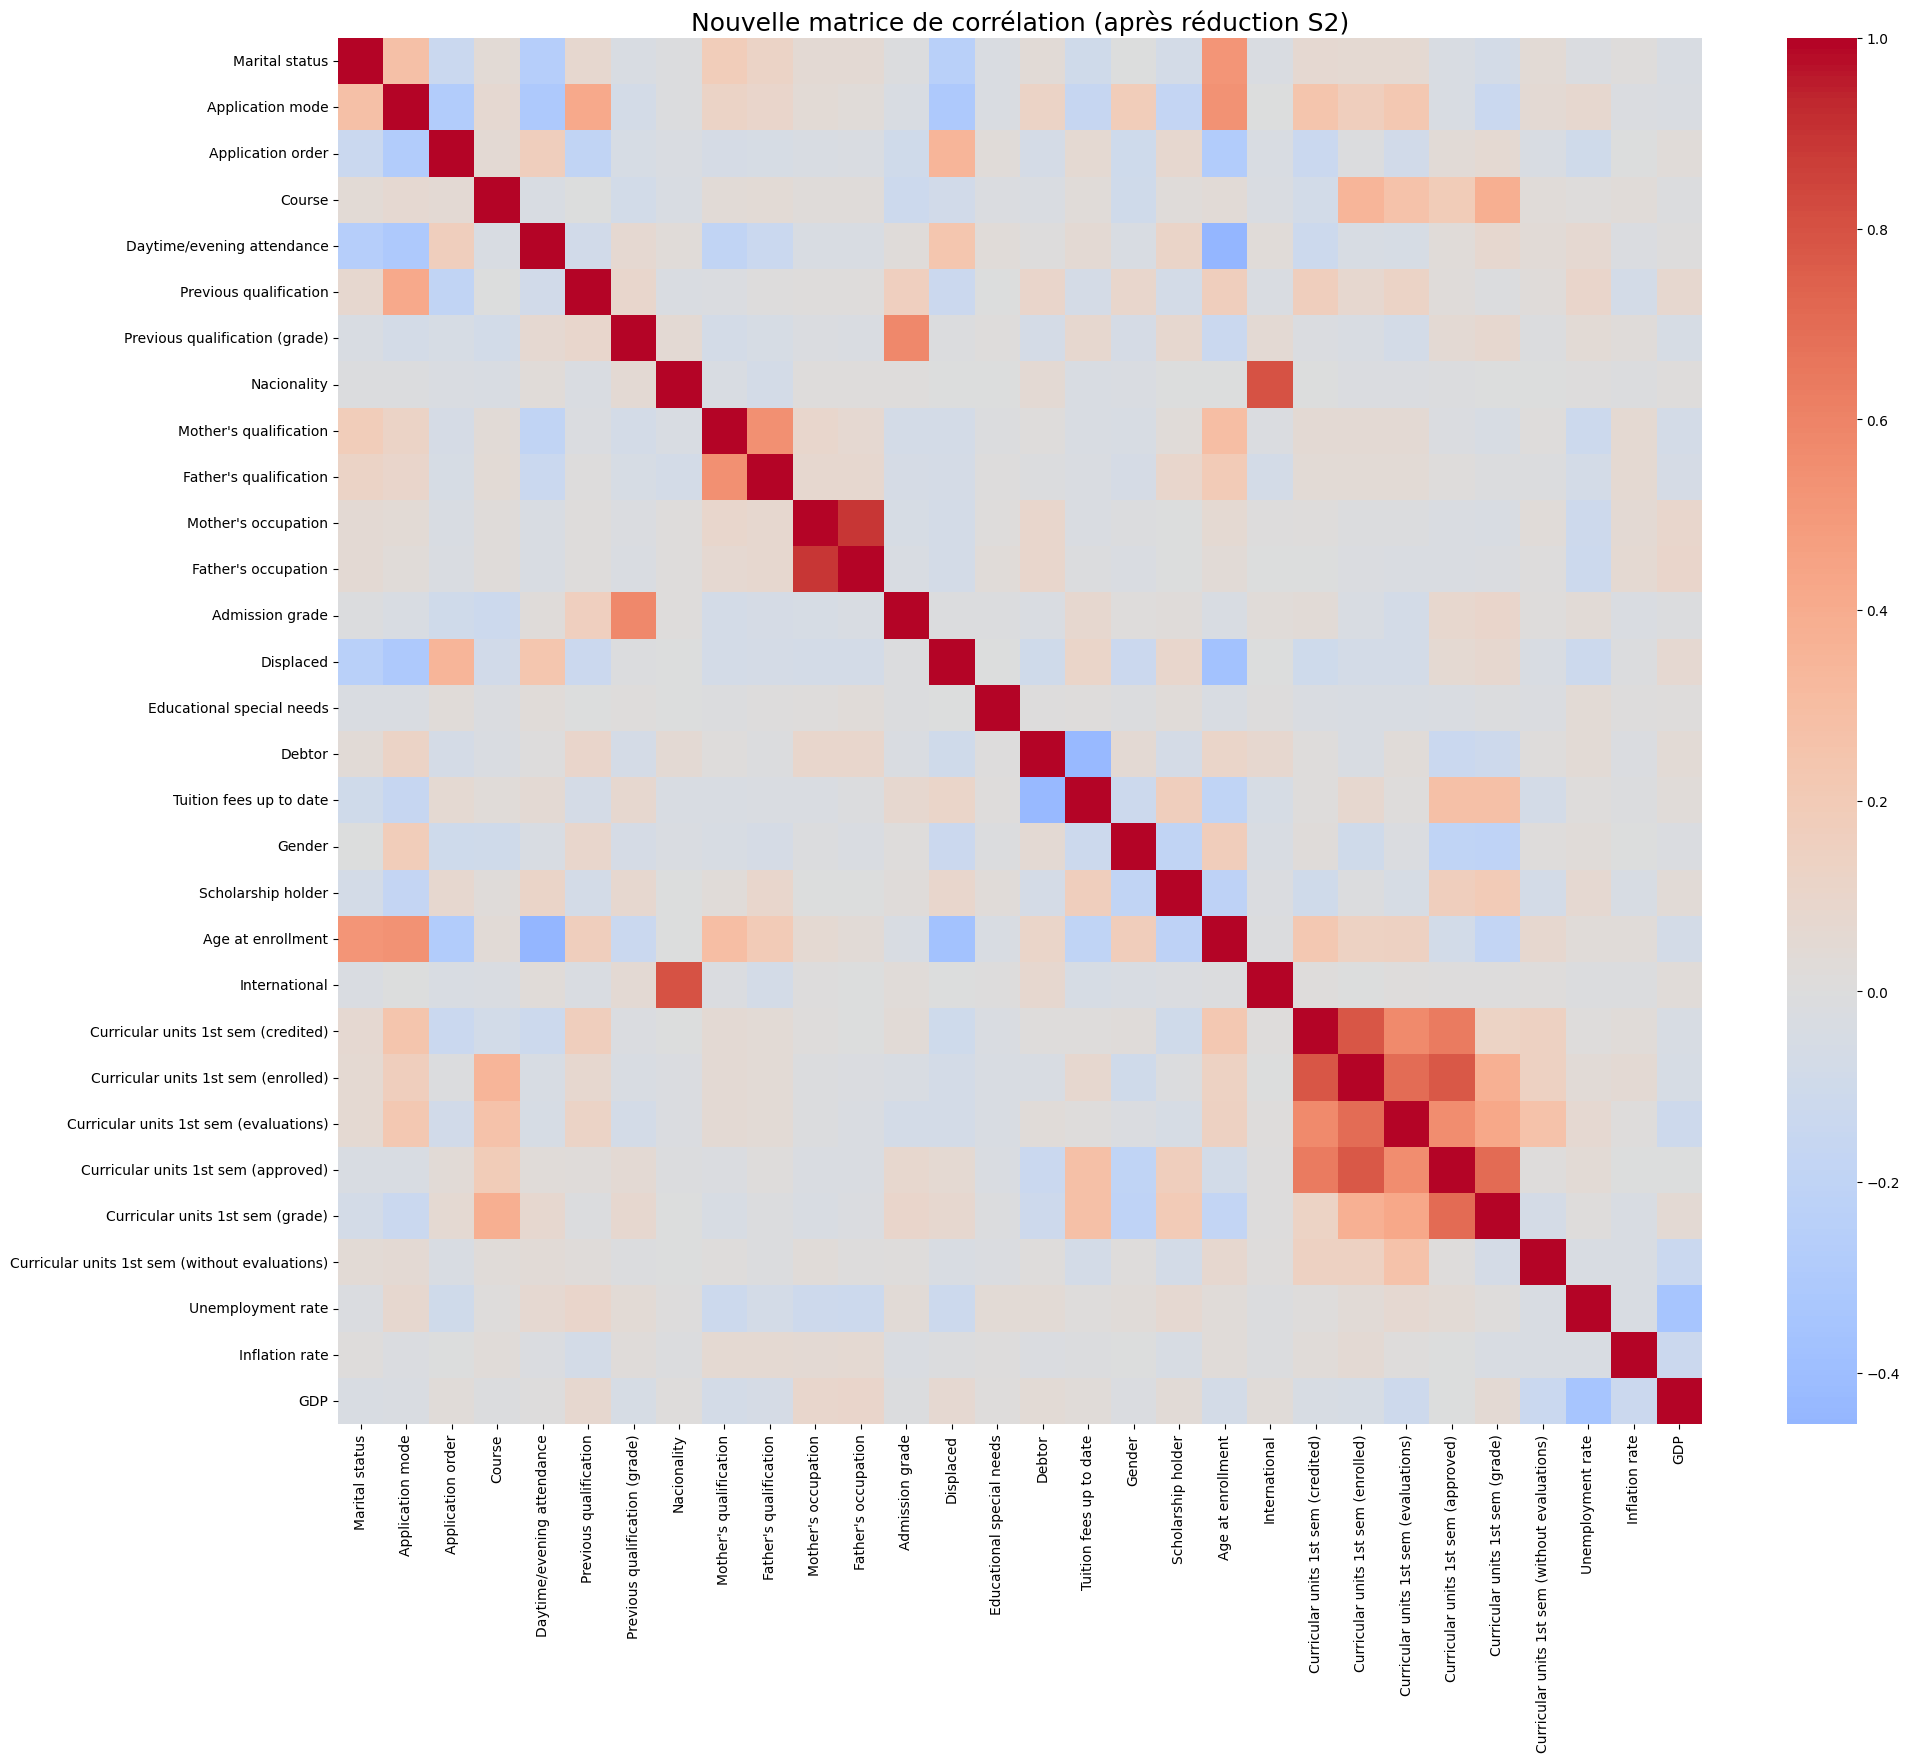

Paires avec corrélation > 0.85 :


Mother's occupation  Father's occupation    0.886568
dtype: float64

In [97]:
numeric_cols_reduced = df_reduced.select_dtypes(include=['int64','float64']).columns.tolist()

plt.figure(figsize=(22, 18))
sns.heatmap(df_reduced[numeric_cols_reduced].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Nouvelle matrice de corrélation (après réduction S2)", fontsize=18)
plt.show()

# Afficher les corrélations > 0.85 restantes
corr_matrix_reduced = df_reduced[numeric_cols_reduced].corr().abs()
high_corr_pairs = (
    corr_matrix_reduced.where(np.triu(np.ones(corr_matrix_reduced.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print("Paires avec corrélation > 0.85 :")
display(high_corr_pairs[high_corr_pairs > 0.85])


Après réduction des variables du second semestre, la matrice de corrélation montre que la plupart des relations fortes ont été éliminées, ce qui réduit efficacement la multicolinéarité. Une seule corrélation très élevée subsiste entre Mother’s occupation et Father’s occupation (r ≈ 0.89), indiquant que ces deux variables apportent presque la même information socio-professionnelle.
Afin d’éviter la redondance et de stabiliser l’entraînement du modèle, nous supprimons Mother's occupation et conservons Father's occupation.
Le dataset est maintenant beaucoup plus cohérent et mieux adapté à la modélisation MLP.

**suppression de la colinéarité parentale**

In [98]:
try:
    df = df_reduced.copy()                 # repartir du df réduit (S2 déjà supprimé)
    df.drop(columns=["Mother's occupation"], inplace=True)
    print("shape:", df.shape)   # devrait être (3630, 30)
except NameError:
    print("df_reduced n'existe pas dans l'environnement — passe à l'Option B.")

shape: (3630, 30)


On passe maintenant à l’étape VIF (Variance Inflation Factor) pour vérifier s’il reste de la multicolinéarité cachée.

**Calcul du VIF**

In [99]:
# On part du df actuel (vérifier Target n'est pas dans les features numériques)
print("Shape avant VIF:", df.shape)

# Sélection des colonnes numériques pour le calcul du VIF
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

# Si 'Target' est numérique par erreur, on l'exclut; ici Target est catégorielle mais on sécurise :
if 'Target' in num_cols:
    num_cols.remove('Target')

X_num = df[num_cols].copy()

# Ajouter une constante (recommandé par statsmodels)
X_num_const = sm.add_constant(X_num, has_constant='add')

# Calculer le VIF pour chaque variable (sauf la constante)
vif_data = []
for i, col in enumerate(X_num.columns):
    vif_val = variance_inflation_factor(X_num_const.values, i+1)  # +1 : index shift à cause de la constante
    vif_data.append((col, vif_val))

vif_df = pd.DataFrame(vif_data, columns=['feature', 'VIF']).sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("\nVIF (par feature) :")
display(vif_df)

# Afficher uniquement celles qui posent problème (VIF > 10 et 5 < VIF <= 10)
print("\nFeatures avec VIF > 10 (forte multicolinéarité) :")
display(vif_df[vif_df['VIF'] > 10])

print("\nFeatures avec 5 < VIF <= 10 (multicolinéarité modérée) :")
display(vif_df[(vif_df['VIF'] > 5) & (vif_df['VIF'] <= 10)])


Shape avant VIF: (3630, 30)

VIF (par feature) :


,feature,VIF
0,Curricular units 1st sem (approved),8.669648
1,Curricular units 1st sem (enrolled),8.099573
2,Curricular units 1st sem (credited),5.154219
3,Curricular units 1st sem (grade),4.366092
4,International,2.781213
5,Nacionality,2.766415
6,Curricular units 1st sem (evaluations),2.636090
7,Age at enrollment,2.331313
8,Course,2.150874
9,Application mode,1.817162



Features avec VIF > 10 (forte multicolinéarité) :


,feature,VIF



Features avec 5 < VIF <= 10 (multicolinéarité modérée) :


,feature,VIF
0,Curricular units 1st sem (approved),8.669648
1,Curricular units 1st sem (enrolled),8.099573
2,Curricular units 1st sem (credited),5.154219


On qu'onstate qu'ucun retrait supplémentaire n’est nécessaire. En effet, les variables restantes sont suffisamment indépendantes pour être utilisées dans un MLP.

**Mutual Information (Importance des variables)**

Top 15 variables les plus informatives :


,Feature,Mutual_Information
23,Curricular units 1st sem (approved),0.269517
24,Curricular units 1st sem (grade),0.194962
15,Tuition fees up to date,0.101189
22,Curricular units 1st sem (evaluations),0.076377
3,Course,0.073132
17,Scholarship holder,0.060641
18,Age at enrollment,0.059641
6,Previous qualification (grade),0.056424
1,Application mode,0.047683
11,Admission grade,0.035961


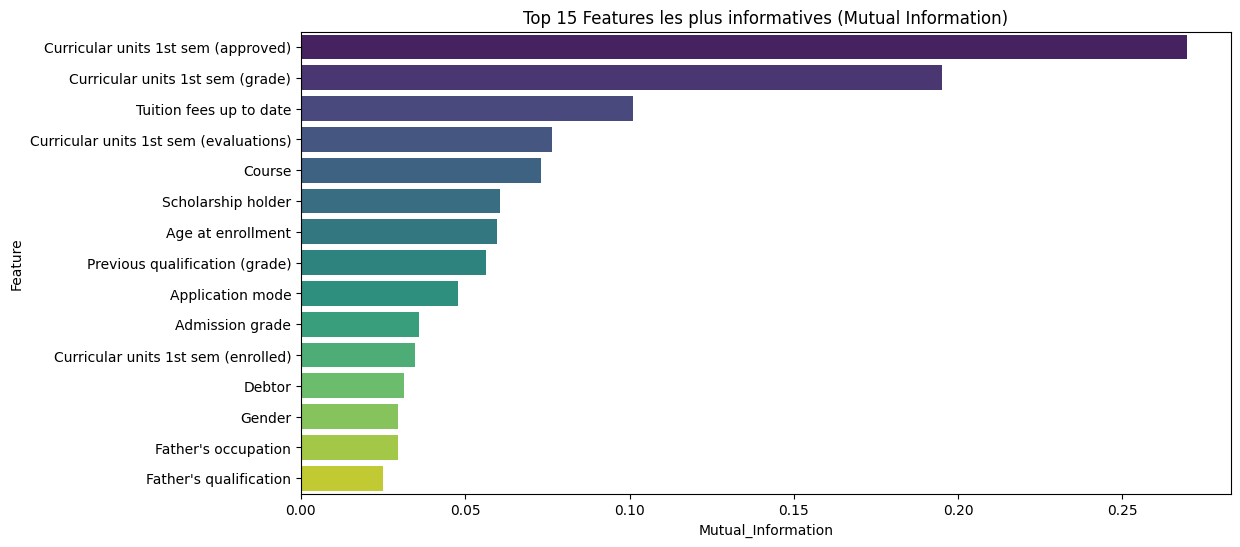

In [100]:
df_mi = df.copy()

# Encode temporairement la cible (Dropout = 0, Graduate = 1)
le = LabelEncoder()
y_mi = le.fit_transform(df_mi["Target"])

# Sélection des features numériques uniquement (MI pour continu)
numeric_features_mi = df_mi.drop(columns=["Target"]).select_dtypes(include=[np.number]).columns

X_mi = df_mi[numeric_features_mi]

# Calcul de la MI
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

mi_df = pd.DataFrame({"Feature": numeric_features_mi,
                      "Mutual_Information": mi_scores})

mi_df = mi_df.sort_values(by="Mutual_Information", ascending=False)

print("Top 15 variables les plus informatives :")
display(mi_df.head(15))

plt.figure(figsize=(12, 6))
sns.barplot(data=mi_df.head(15), x="Mutual_Information", y="Feature", palette="viridis")
plt.title("Top 15 Features les plus informatives (Mutual Information)")
plt.show()


La Mutual Information montre que les performances académiques du 1er semestre
(notamment approved, grade et evaluations) sont les facteurs les plus informatifs
pour prédire si un étudiant décroche ou réussit.
Plusieurs variables socio-économiques (bourse, frais à jour, âge, qualification précédente) ont une importance moyenne mais complémentaire.
Les variables comme Gender, Debtor, Admission grade ou les occupations parentales
ont une influence faible isolément, mais elles sont conservées car elles peuvent contribuer en interaction dans le MLP.

Pour le moment, aucune variable numérique n’est éliminée sur la base de la MI.

**Analyse des variables catégorielles**

In [101]:
# Sélection des colonnes catégorielles
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Colonnes catégorielles :", categorical_cols)

# Analyse des valeurs uniques
cat_summary = {}

for col in categorical_cols:
    values = df[col].value_counts()
    rare = (values / len(df)) < 0.01  # catégories représentant <1%
    
    cat_summary[col] = {
        "nb_categories": values.nunique(),
        "top_categories": values.head(10),
        "rare_categories": values[rare]
    }

    print(f"\n VARIABLE : {col}")
    print(f"Nombre de catégories : {values.nunique()}")
    print("\nTop 10 catégories :")
    print(values.head(10))
    print("\nCatégories rares (<1%) :")
    print(values[rare])

# stocker ce résumé pour usage ultérieur
cat_summary


Colonnes catégorielles : ['Target']

 VARIABLE : Target
Nombre de catégories : 2

Top 10 catégories :
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Catégories rares (<1%) :
Series([], Name: count, dtype: int64)


{'Target': {'nb_categories': 2,
  'top_categories': Target
  Graduate    2209
  Dropout     1421
  Name: count, dtype: int64,
  'rare_categories': Series([], Name: count, dtype: int64)}}

L'inspection après nettoyage, montre que, seule la variable Target est réellement catégorielle dans le dataset. Elle contient deux classes : Graduate (majoritaire) et Dropout, sans catégorie rare.
La distribution est modérément déséquilibrée mais exploitable.
Cette variable sera simplement encodée en binaire (0/1) pour l’entraînement.

**Cellule A: détecter les colonnes catégorielles "codées en int"**


In [102]:
# Liste des colonnes traitées (df doit être le df nettoyé courant)
print("Shape du df :", df.shape)
print()

# Colonnes object (vraies catégorielles)
obj_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Colonnes numériques entières qui semblent être des catégories (faible nombre d'uniques)
int_cols = df.select_dtypes(include=['int64']).columns.tolist()

# Pour chaque int_col, afficher le nombre d'uniques et un aperçu
cat_like = []
print("Colonnes object (vraies catégorielles) :", obj_cols)
print()
print("Colonnes entières (possibles catégorielles) et cardinalités :")
for c in int_cols:
    nunq = df[c].nunique()
    pct_unique = nunq / len(df)
    sample = df[c].value_counts().head(5)
    print(f"- {c} : n_unique={nunq}, pct_unique={pct_unique:.3f} ; top5 ->")
    print(sample.to_string())
    print()
    # heuristique : si moins de 50 uniques ou moins de 0.05 proportion -> considérer comme catégorielle
    if nunq <= 50 or pct_unique < 0.05:
        cat_like.append(c)

print("→ Colonnes candidates catégorielles (heuristique) :", cat_like)


Shape du df : (3630, 30)

Colonnes object (vraies catégorielles) : ['Target']

Colonnes entières (possibles catégorielles) et cardinalités :
- Marital status : n_unique=6, pct_unique=0.002 ; top5 ->
Marital status
1    3199
2     327
4      75
5      22
6       5

- Application mode : n_unique=18, pct_unique=0.005 ; top5 ->
Application mode
1     1408
17     713
39     664
43     237
44     157

- Application order : n_unique=7, pct_unique=0.002 ; top5 ->
Application order
1    2461
2     451
3     249
4     218
5     129

- Course : n_unique=17, pct_unique=0.005 ; top5 ->
Course
9500    666
9238    313
9773    297
9147    272
9085    262

- Daytime/evening attendance : n_unique=2, pct_unique=0.001 ; top5 ->
Daytime/evening attendance
1    3222
0     408

- Previous qualification : n_unique=17, pct_unique=0.005 ; top5 ->
Previous qualification
1     3019
39     164
19     149
3      122
12      39

- Nacionality : n_unique=19, pct_unique=0.005 ; top5 ->
Nacionality
1     3544
41      3

L’exploration des types de variables montre que, même si seule Target apparaît comme une colonne de type object, plusieurs colonnes numériques (int64) représentent en réalité des codes catégoriels : codes de statut marital, modes d’application, types de qualifications, codes de cours, etc.
Ces valeurs ne sont pas continues mais symbolisent des catégories distinctes.

Identifier correctement ces variables est essentiel, car elles doivent être encodées et non normalisées, contrairement aux vraies variables numériques.

**Cellule B: proposer stratégie d'encodage automatique**


In [103]:

# paramètres 
onehot_thresh = 20       # cardinalité <= 20 -> one-hot
ordinal_thresh = 100     # cardinalité <= 100 -> ordinal/freq possible

# Construire la liste des colonnes catégorielles réelles (obj + cat_like)
cat_candidates = obj_cols + cat_like
cat_candidates = [c for c in cat_candidates if c != 'Target']  # target exclue

onehot_cols = []
freq_cols = []
high_card_cols = []

for c in cat_candidates:
    k = df[c].nunique()
    if k <= onehot_thresh:
        onehot_cols.append(c)
    elif k <= ordinal_thresh:
        freq_cols.append(c)
    else:
        high_card_cols.append(c)

print("One-hot candidates (<= {} uniques) :".format(onehot_thresh))
print(onehot_cols)
print("\nFrequency/Ordinal candidates (<= {} uniques) :".format(ordinal_thresh))
print(freq_cols)
print("\nHigh-cardinality (> {} uniques) :".format(ordinal_thresh))
print(high_card_cols)


One-hot candidates (<= 20 uniques) :
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International', 'Curricular units 1st sem (without evaluations)']

Frequency/Ordinal candidates (<= 100 uniques) :
["Mother's qualification", "Father's qualification", "Father's occupation", 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)']

High-cardinality (> 100 uniques) :
[]


Cette étape nous permet d’identifier le type d’encodage optimal pour chaque variable catégorielle. Sur base du nombre de valeurs uniques :

Variables à faible cardinalité (≤ 20 catégories)
  - Bon candidates pour un One-Hot Encoding, car elles représentent de véritables catégories discrètes :
Marital status, Application mode, Debtor, Gender, Displaced, etc.

Variables à cardinalité moyenne (20 à 100 catégories)
  - À encoder via Ordinal/Frequency Encoding pour éviter une explosion du nombre de colonnes :
Mother’s qualification, Father’s occupation, Age at enrollment, et les variables de performance du 1ᵉʳ semestre.

Aucune variable à haute cardinalité (> 100)
  - Le dataset est donc simple à encoder et ne nécessite pas de techniques d’encodage avancées.

**Encodage complet**


In [104]:
df_encoded = df.copy()

# Définition des groupes de variables 
one_hot_cols = ['Marital status', 'Application mode', 'Application order', 'Course',
                'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
                'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date',
                'Gender', 'Scholarship holder', 'International',
                'Curricular units 1st sem (without evaluations)']

ordinal_cols = ["Mother's qualification", "Father's qualification", "Father's occupation",
                'Age at enrollment', 'Curricular units 1st sem (credited)',
                'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
                'Curricular units 1st sem (approved)']

# Colonnes numériques restantes :
num_cols = [col for col in df_encoded.columns
            if col not in one_hot_cols + ordinal_cols + ['Target']]

print("One-Hot:", len(one_hot_cols), one_hot_cols)
print("Ordinal:", len(ordinal_cols), ordinal_cols)
print("Num:", len(num_cols), num_cols)

# Pipeline encodeurs
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_cols),
        ('ordinal', OrdinalEncoder(), ordinal_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Séparation X / y
X = df_encoded.drop(columns=['Target'])
y = df_encoded['Target'].map({'Graduate': 1, 'Dropout': 0})   

# Application du préprocesseur
X_encoded = preprocessor.fit_transform(X)

print("\nShape original :", X.shape)
print("Shape après encodage :", X_encoded.shape)

# Sauvegarde du préprocesseur pour la modélisation
joblib.dump(preprocessor, "preprocessor.pkl")


One-Hot: 15 ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International', 'Curricular units 1st sem (without evaluations)']
Ordinal: 8 ["Mother's qualification", "Father's qualification", "Father's occupation", 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)']
Num: 6 ['Previous qualification (grade)', 'Admission grade', 'Curricular units 1st sem (grade)', 'Unemployment rate', 'Inflation rate', 'GDP']

Shape original : (3630, 29)
Shape après encodage : (3630, 125)


['preprocessor.pkl']

Après encodage, nos variables sont correctement transformées pour être utilisées dans un MLP :

  - 15 variables One-Hot : ce sont des catégories sans ordre (ex : genre, dettes…). On les encode en colonnes binaires pour éviter d’imposer un ordre artificiel.

  - 8 variables Ordinal : ce sont des catégories avec un ordre logique (ex : qualification, crédits obtenus…). On utilise un encodage numérique simple pour garder cette hiérarchie.

  - 6 variables numériques : elles restent inchangées car ce sont de vraies valeurs continues (notes, taux économiques…).

Le dataset passe logiquement de 29 à 125 colonnes, car le One-Hot crée plusieurs colonnes nouvelles.
Cette transformation met toutes les variables dans un format mathématique cohérent et directement utilisable pour entraîner un réseau de neurones.

**Encodage du Target**

In [105]:
df_encoded['Target_num'] = df_encoded['Target'].map({
    'Graduate': 1,
    'Dropout': 0
})

# Vérification
print(df_encoded['Target_num'].value_counts())
print(df_encoded[['Target','Target_num']].head())


Target_num
1    2209
0    1421
Name: count, dtype: int64
     Target  Target_num
0   Dropout           0
1  Graduate           1
2   Dropout           0
3  Graduate           1
4  Graduate           1


Voici une conversion de la colonne target en une version numérique Target_num indispensable pour l’apprentissage.

Cette répartition montre un déséquilibre modéré (environ 60% et 40%), ce qui estacceptable pour entraîner un MLP.

**Analyse en Composantes Principales**

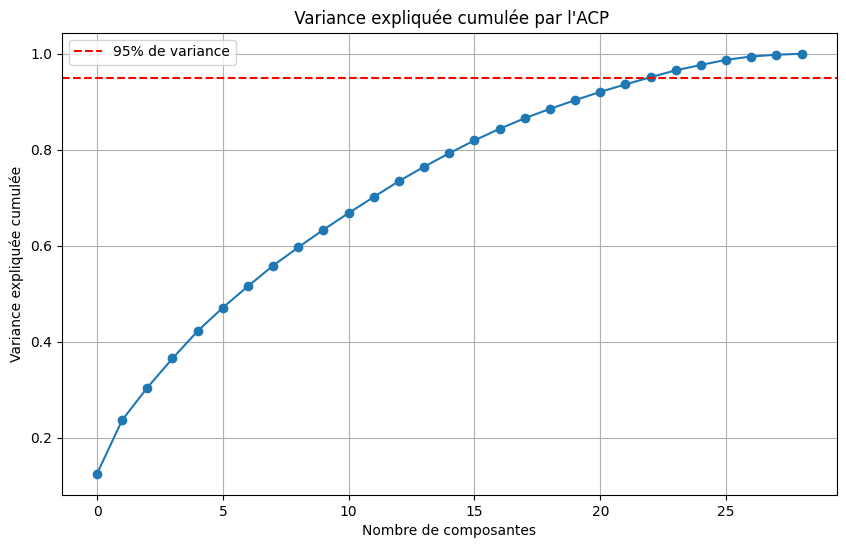

 Nombre de composantes nécessaires pour expliquer 95% de la variance : 23
Shape avant ACP : (3630, 29)
Shape après ACP : (3630, 23)


In [106]:
# Séparation features / target
X = df_encoded.drop(columns=['Target', 'Target_num'])
y = df_encoded['Target_num']

# Standardisation 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP sans préciser n_composants : on garde tout pour analyser
pca = PCA()
pca.fit(X_scaled)

# Variance expliquée cumulée
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(explained_variance, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% de variance')
plt.title(" Variance expliquée cumulée par l'ACP")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.grid(True)
plt.legend()
plt.show()

# Déterminer automatiquement le nb de composantes pour 95% de variance
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print(f" Nombre de composantes nécessaires pour expliquer 95% de la variance : {n_components_95}")

# Nouvelle ACP avec seulement les composantes utiles
pca_final = PCA(n_components=n_components_95)
X_pca = pca_final.fit_transform(X_scaled)

print("Shape avant ACP :", X.shape)
print("Shape après ACP :", X_pca.shape)


boruta